# Exploratory Data Analysis — SeizeIT2 seizure prediction

Exploratory Data Analysis (EDA) inspects the data **before** modelling: how many seizures each
patient has, how imbalanced the classes are, how long recordings last, and what the raw signals
look like. The goal is to understand the dataset, surface surprises early, and produce figures
for the Methodology chapter.

**Memory note.** Sections 1–5 are lightweight: they read the BIDS `events.tsv` annotations and
only the small arrays inside the `.npz` (labels, indices) — the multi-GB signal array `X` is
never loaded. Section 6 is the only heavy part; it loads `X` for the EEG set once (and frees it
afterwards) and is clearly marked as optional. The EEG+ECG `.npz` is never loaded here.

All figures are written to `../results/eda/`.

In [1]:
import csv
import sys
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, '../src')
from preprocess_common import (
    discover_recordings, parse_seizure_events, _subject_from_path,
)

RAW = Path('../data/raw/seizeit2')
DATA = Path('../data/processed/eeg_windows.npz')   # EEG set only
OUT = Path('../results/eda')
OUT.mkdir(parents=True, exist_ok=True)

recs = discover_recordings(RAW)
print(f'Recordings discovered : {len(recs)}')
print(f'Subjects              : {len(set(r.subject for r in recs))}')
print(f'Figures -> {OUT.resolve()}')

Recordings discovered : 486
Subjects              : 60
Figures -> C:\Users\yordi\Desktop\capstone-project\results\eda


## 1. Dataset overview

How many recordings actually contain a seizure, how many seizure events there are in total, and
which seizure types occur. Recordings without a seizure contribute no pre-ictal windows and are
dropped by the preprocessing, so this count tells us how much usable data there is.

*(Lightweight — reads `events.tsv` only.)*

In [2]:
rows = []            # (subject, run, n_seizures)
sz_types = Counter()
for r in recs:
    szs = parse_seizure_events(r.events_path)
    if r.events_path and Path(r.events_path).exists():
        with open(r.events_path, encoding='utf-8') as f:
            for row in csv.DictReader(f, delimiter='\t'):
                et = (row.get('eventType') or '').strip()
                if et.startswith('sz'):
                    sz_types[et] += 1
    rows.append((r.subject, r.run, len(szs)))

n_sz = sum(n for *_, n in rows)
recs_with_sz = sum(1 for *_, n in rows if n > 0)
subs_with_sz = len(set(s for s, _, n in rows if n > 0))
print(f'Total seizure events          : {n_sz}')
print(f'Recordings with >= 1 seizure  : {recs_with_sz} / {len(recs)}')
print(f'Subjects with >= 1 seizure    : {subs_with_sz}')
print('\nSeizure types:')
for t, c in sz_types.most_common():
    print(f'  {t:<30} {c}')

Total seizure events          : 440
Recordings with >= 1 seizure  : 144 / 486
Subjects with >= 1 seizure    : 60

Seizure types:
  sz_foc_a_m_hyperkinetic        95
  sz_foc_ia_nm                   72
  sz_foc_ia_m_hyperkinetic       72
  sz_foc_a_nm                    44
  sz_foc_ua_um                   33
  sz_foc_ua_nm                   31
  sz_foc_ia_m_automatisms        20
  sz_foc_f2b                     18
  sz_foc_ia_m_tonic              16
  sz_foc_ua_nm_behavior          9
  sz_foc_ia                      6
  sz_foc_ua_m_hyperkinetic       5
  sz_foc_a_m_automatisms         3
  sz_foc_a_nm_behavior           3
  sz_foc_ua_m                    3
  sz_foc_ua_m_tonic              2
  sz_foc_ua_m_automatisms        2
  sz_foc_a_um                    2
  sz_foc_ia_nm_behavior          1
  sz_foc_ia_m_clonic             1
  sz_foc_ia_um                   1
  sz_uo_nm                       1


## 2. Seizures per subject

The number of seizures varies a lot between patients. This heterogeneity is central to the
project: patients with few seizures contribute few pre-ictal windows, which makes their
per-subject metrics unstable.

*(Lightweight — `events.tsv` only.)*

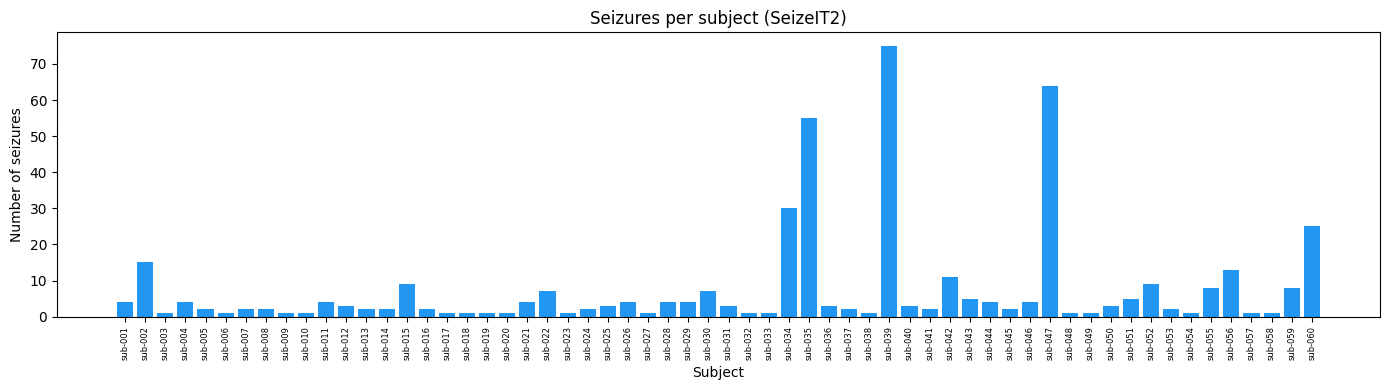

min 1  max 75  mean 7.3  median 3


In [3]:
sz_per_subj = defaultdict(int)
for s, _, n in rows:
    sz_per_subj[s] += n
subs = sorted(sz_per_subj)
counts = [sz_per_subj[s] for s in subs]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(subs)), counts, color='#2196F3')
ax.set_xticks(range(len(subs)))
ax.set_xticklabels(subs, rotation=90, fontsize=6)
ax.set_ylabel('Number of seizures')
ax.set_xlabel('Subject')
ax.set_title('Seizures per subject (SeizeIT2)')
fig.tight_layout()
fig.savefig(OUT / 'seizures_per_subject.png', dpi=150)
plt.show()
print(f'min {min(counts)}  max {max(counts)}  '
      f'mean {np.mean(counts):.1f}  median {np.median(counts):.0f}')

## 3. Seizure and recording durations

Seizure duration motivates the post-ictal guard length; recording duration (≈ hours) shows why
keeping every interictal window is infeasible and why interictal subsampling is needed.

*(Lightweight — `events.tsv` only.)*

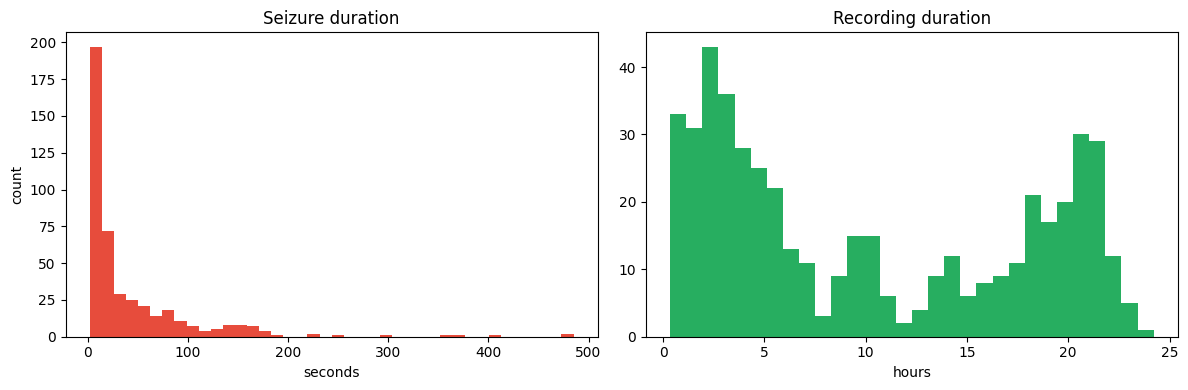

Seizure duration  : median 17s  max 485s
Recording duration: median 8.1h  max 24.2h


In [4]:
sz_durs, rec_durs = [], []
for r in recs:
    for _onset, dur in parse_seizure_events(r.events_path):
        sz_durs.append(dur)
    if r.events_path and Path(r.events_path).exists():
        with open(r.events_path, encoding='utf-8') as f:
            first = next(csv.DictReader(f, delimiter='\t'), None)
        if first and first.get('recordingDuration'):
            try:
                rec_durs.append(float(first['recordingDuration']) / 3600.0)
            except ValueError:
                pass

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(sz_durs, bins=40, color='#E74C3C')
axes[0].set_title('Seizure duration')
axes[0].set_xlabel('seconds')
axes[0].set_ylabel('count')
axes[1].hist(rec_durs, bins=30, color='#27AE60')
axes[1].set_title('Recording duration')
axes[1].set_xlabel('hours')
fig.tight_layout()
fig.savefig(OUT / 'durations.png', dpi=150)
plt.show()
print(f'Seizure duration  : median {np.median(sz_durs):.0f}s  max {np.max(sz_durs):.0f}s')
print(f'Recording duration: median {np.median(rec_durs):.1f}h  max {np.max(rec_durs):.1f}h')

## 4. Class balance (preprocessed dataset)

We open the `.npz` but read **only the label array `y` and metadata** — the signal array `X`
(several GB) is never touched, so this stays light. A `.npz` stores each array separately, so
accessing `npz['y']` does not load `npz['X']`.

Note the raw imbalance is far more extreme (interictal outnumbers pre-ictal by roughly 50:1 or
more over the full recordings). The dataset below is **after** interictal subsampling, so it
reflects the target ~5:1 ratio the model actually trains on.

normalize=per_recording  preictal_sec=600  interictal_ratio=5
Windows total : 1,095,773
Pre-ictal     : 185,161 (16.9%)
Interictal    : 910,612 (83.1%)
Ratio interictal:pre-ictal = 4.9 : 1


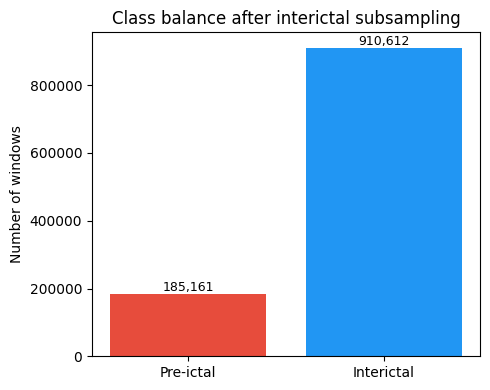

In [5]:
# Lazy access: read only the small arrays, never npz['X'].
npz = np.load(DATA, allow_pickle=False)
y = npz['y']
file_slices = [tuple(int(v) for v in row) for row in npz['file_slices']]
recording_paths = [Path(p) for p in npz['recording_paths']]
meta = {k: npz[k] for k in ('interictal_ratio', 'preictal_sec', 'window_sec', 'normalize')
        if k in npz}
channel_names = [str(c) for c in npz['channel_names']]

n_pre = int((y == 1).sum())
n_int = int((y == 0).sum())
print(f'normalize={str(meta.get("normalize"))}  preictal_sec={float(meta["preictal_sec"]):.0f}  '
      f'interictal_ratio={float(meta["interictal_ratio"]):.0f}')
print(f'Windows total : {len(y):,}')
print(f'Pre-ictal     : {n_pre:,} ({100*n_pre/len(y):.1f}%)')
print(f'Interictal    : {n_int:,} ({100*n_int/len(y):.1f}%)')
print(f'Ratio interictal:pre-ictal = {n_int/n_pre:.1f} : 1')

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Pre-ictal', 'Interictal'], [n_pre, n_int], color=['#E74C3C', '#2196F3'])
for b, v in zip(bars, [n_pre, n_int]):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:,}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Number of windows')
ax.set_title('Class balance after interictal subsampling')
fig.tight_layout()
fig.savefig(OUT / 'class_balance.png', dpi=150)
plt.show()

## 5. Windows per subject

How the kept windows (and the pre-ictal subset) are distributed across patients. A few subjects
dominate the dataset, which is worth keeping in mind when interpreting pooled metrics.

*(Lightweight — uses the `y` and index arrays loaded above; `X` still untouched.)*

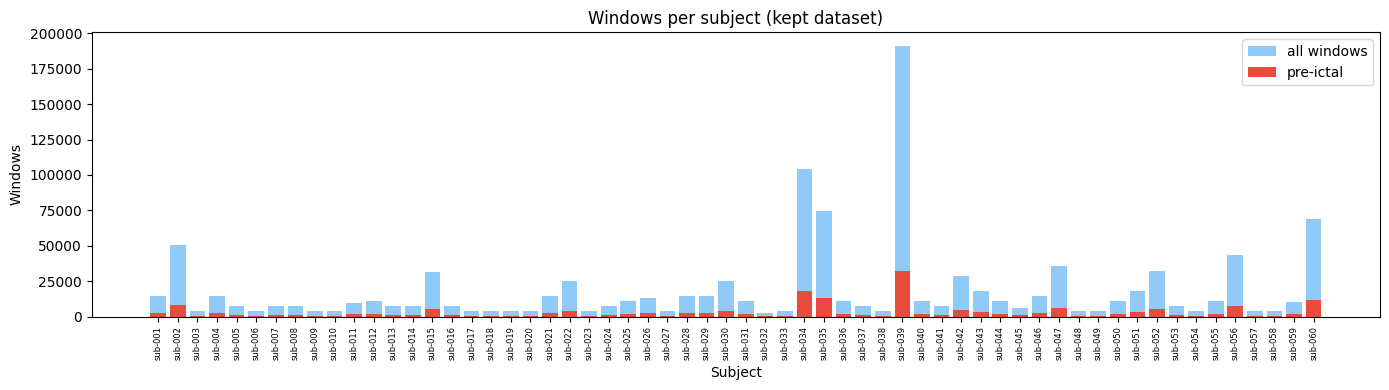

In [6]:
subj_of = np.empty(len(y), dtype=object)
for (s, e), p in zip(file_slices, recording_paths):
    subj_of[s:e] = _subject_from_path(p)

subs2 = sorted(set(subj_of))
all_w = [int((subj_of == s).sum()) for s in subs2]
pre_w = [int(((subj_of == s) & (y == 1)).sum()) for s in subs2]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(subs2)), all_w, color='#90CAF9', label='all windows')
ax.bar(range(len(subs2)), pre_w, color='#E74C3C', label='pre-ictal')
ax.set_xticks(range(len(subs2)))
ax.set_xticklabels(subs2, rotation=90, fontsize=6)
ax.set_ylabel('Windows')
ax.set_xlabel('Subject')
ax.set_title('Windows per subject (kept dataset)')
ax.legend()
fig.tight_layout()
fig.savefig(OUT / 'windows_per_subject.png', dpi=150)
plt.show()